# Functional Analysis

This notebook follows **Chapter 5, "Functional Analysis"**, of:

> Haitz Sáez de Ocáriz Borde and Michael Bronstein,  
> *Mathematical Foundations of Geometric Deep Learning*, arXiv:2508.02723.

The source chapter is deliberately short. It introduces the basic ideas needed later for **spectral theory**: Cauchy sequences, Banach spaces, Hilbert spaces, $L^2$ as an infinite-dimensional vector space, operators, functionals, dual spaces, and weak/strong convergence.

Here we expand those ideas with additional examples, non-examples, and computational experiments.

We will not repeat material already developed in earlier notebooks:

- vector spaces and linear combinations → `03_linear_spaces.ipynb`;
- norms, metrics, and inner products → `03_linear_spaces.ipynb`;
- numerical integration of function inner products → `03_linear_spaces.ipynb`.

The main new idea is that in functional analysis, the vectors themselves may be **functions or infinite sequences**, so the familiar geometry of finite-dimensional linear algebra has to be extended carefully.

## 1. Why functional analysis?

In ordinary linear algebra we often work with

$$
\mathbb R^n
$$

and represent a vector by a finite list of coordinates.

Functional analysis asks what happens when the objects we want to manipulate form spaces such as

$$
C([0,1]),\qquad
L^2([0,1]),\qquad
\ell^2,\qquad
\ell^p.
$$

These spaces can be infinite-dimensional.

For example, a function

$$
f:[0,1]\to\mathbb R
$$

cannot in general be specified by finitely many coordinates. Nevertheless, it can be treated as a vector:

$$
f+g,\qquad
\alpha f,\qquad
\|f\|,\qquad
\langle f,g\rangle.
$$

Functional analysis studies the resulting spaces and, importantly, the **maps between them**.

The source chapter emphasizes that this provides the mathematical foundation for later spectral theory, where operators such as the Laplacian act on spaces of functions.

## 2. Cauchy sequences

Let $(V,\|\cdot\|)$ be a normed vector space.

A sequence

$$
v_1,v_2,v_3,\ldots
$$

is called **Cauchy** if

$$
\forall\epsilon>0,\quad
\exists N\in\mathbb N
\quad\text{such that}\quad
m,n>N
\Longrightarrow
\|v_m-v_n\|<\epsilon.
$$

The important point is that this definition talks only about the terms becoming close to **one another**.

It does not explicitly say that the sequence converges to an element of $V$.

The source gives the example

$$
d_n=1-\frac1n.
$$

This sequence is Cauchy in both $(0,1]$ and $(0,1)$, but its limit $1$ belongs to the first space and not the second. 

### Example: a Cauchy sequence in $\mathbb R$

Consider

$$
x_n=\frac1n.
$$

For $m,n$ sufficiently large, both $1/m$ and $1/n$ are close to zero, so

$$
|x_m-x_n|
=
\left|\frac1m-\frac1n\right|
\to 0.
$$

The sequence converges to $0$, and therefore it is Cauchy.

In $\mathbb R$, every Cauchy sequence converges in $\mathbb R$.

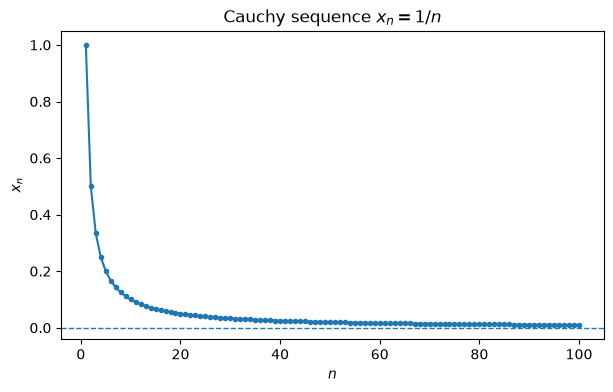

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 101)
x = 1 / n

plt.figure(figsize=(7, 4))
plt.plot(n, x, marker=".")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$n$")
plt.ylabel(r"$x_n$")
plt.title(r"Cauchy sequence $x_n=1/n$")
plt.show()

### Non-example: a sequence that is not Cauchy

Consider

$$
x_n=(-1)^n.
$$

The sequence keeps jumping between $-1$ and $1$.

For example,

$$
|x_{2n}-x_{2n+1}|=2,
$$

for every $n$. Therefore its terms never become arbitrarily close to one another.

So the sequence is **not Cauchy**.

Notice that this is stronger than merely saying that it does not converge: a non-convergent sequence need not automatically fail to be Cauchy unless the ambient space is complete.

## 3. Completeness

A normed vector space is **complete** if every Cauchy sequence converges to an element of the space.

Completeness is therefore a property of the **space**, not of an individual sequence.

This distinction is fundamental:

$$
\boxed{
\text{Cauchy}
\neq
\text{convergent in the space}.
}
$$

A space may contain sequences whose terms become arbitrarily close but whose limiting object is missing from the space.

The source illustrates this with

$$
(0,1)
$$

and

$$
d_n=1-\frac1n,
$$

whose limit is $1\notin(0,1)$.

### A particularly important non-example: $\mathbb Q$

With the usual absolute-value norm,

$$
\mathbb Q
$$

is not complete.

Take rational approximations to $\sqrt2$:

$$
q_1,q_2,\ldots\in\mathbb Q,
\qquad
q_n\to\sqrt2.
$$

The sequence is Cauchy in $\mathbb Q$, but

$$
\sqrt2\notin\mathbb Q.
$$

Thus $\mathbb Q$ has a "hole" from the point of view of Cauchy convergence.

Its completion is $\mathbb R$.

This example is conceptually useful: **completing a space means adding the missing limits required by its Cauchy sequences.**

In [2]:
# Rational approximations obtained by truncating the decimal expansion of sqrt(2).
sqrt2 = np.sqrt(2)
q = np.array([np.floor(sqrt2 * 10**k) / 10**k for k in range(1, 10)])

print("Rational approximations:")
for k, value in enumerate(q, start=1):
    print(f"{k}: {value}")

print("\nFinal approximation:", q[-1])
print("sqrt(2):            ", sqrt2)

Rational approximations:
1: 1.4
2: 1.41
3: 1.414
4: 1.4142
5: 1.41421
6: 1.414213
7: 1.4142135
8: 1.41421356
9: 1.414213562

Final approximation: 1.414213562
sqrt(2):             1.4142135623730951


## 4. Banach spaces

A **Banach space** is a complete normed vector space.

Thus:

$$
\boxed{
\text{Banach space}
=
\text{normed vector space}
+
\text{completeness}.
}
$$

Banach spaces are the natural setting when convergence is measured using a norm but no inner product is available or needed.

The source gives the sequence spaces $\ell^p$, $1\leq p<\infty$, as fundamental examples. 

### Example 1: $\mathbb R^n$

Every finite-dimensional normed vector space is complete.

Thus

$$
(\mathbb R^n,\|\cdot\|_p)
$$

is a Banach space for every

$$
1\leq p\leq\infty.
$$

This includes the familiar Euclidean space

$$
(\mathbb R^n,\|\cdot\|_2).
$$

So Banach spaces are not necessarily infinite-dimensional. Functional analysis becomes especially interesting because the same ideas continue to work in infinite-dimensional settings.

### Example 2: the sequence spaces $\ell^p$

For $1\leq p<\infty$,

$$
\ell^p
=
\left\{
x=(x_1,x_2,\ldots):
\sum_{n=1}^{\infty}|x_n|^p<\infty
\right\},
$$

with norm

$$
\|x\|_p
=
\left(
\sum_{n=1}^{\infty}|x_n|^p
\right)^{1/p}.
$$

These are Banach spaces.

The most important special case for our purposes will be

$$
\ell^2,
$$

because $\ell^2$ is not only Banach but also a Hilbert space.

### Example 3: $C([0,1])$

Let

$$
C([0,1])
=
\{f:[0,1]\to\mathbb R:f\text{ is continuous}\}.
$$

With the supremum norm

$$
\|f\|_\infty
=
\sup_{x\in[0,1]}|f(x)|,
$$

this is a Banach space.

The completeness is worth appreciating: if continuous functions become uniformly closer and closer to one another, their limit is again a continuous function.

This is one reason the supremum norm is natural for uniform approximation.

### Non-example: polynomials with the supremum norm

Let

$$
\mathcal P([0,1])
$$

denote the space of polynomials restricted to $[0,1]$, with the same supremum norm.

This normed space is **not complete**.

There are sequences of polynomials that converge uniformly to continuous functions that are not polynomials.

For example, the Weierstrass approximation theorem says that every continuous function can be uniformly approximated by polynomials. Therefore the completion of $\mathcal P([0,1])$ under $\|\cdot\|_\infty$ is $C([0,1])$.

This gives a useful interpretation of completion:

$$
\overline{\mathcal P}^{\,\|\cdot\|_\infty}
=
C([0,1]).
$$

## 5. Different norms give different Banach spaces

The same underlying vector space can behave very differently under different norms.

For sequences, compare

$$
\ell^1,\qquad
\ell^2,\qquad
\ell^\infty.
$$

For example,

$$
x_n=\frac1n
$$

does not belong to $\ell^1$, because

$$
\sum_{n=1}^{\infty}\frac1n=\infty.
$$

But it does not belong to $\ell^2$ either? Indeed,

$$
\sum_{n=1}^{\infty}\frac1{n^2}<\infty,
$$

so it **does** belong to $\ell^2$.

It also belongs to $\ell^\infty$, since it is bounded.

Thus

$$
\frac1n\in\ell^2\cap\ell^\infty,
\qquad
\frac1n\notin\ell^1.
$$

The choice of norm is therefore not merely notation; it determines which infinite objects belong to the space and what convergence means.

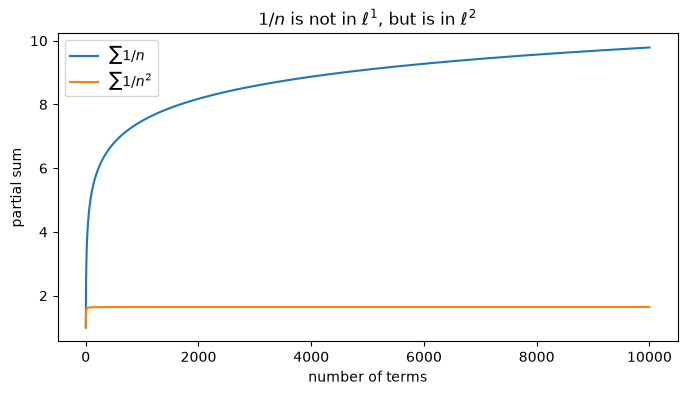

In [3]:
# Partial sums illustrate the difference between l^1 and l^2.
n = np.arange(1, 10001)

partial_l1 = np.cumsum(1 / n)
partial_l2 = np.cumsum(1 / n**2)

plt.figure(figsize=(8, 4))
plt.plot(n, partial_l1, label=r"$\sum 1/n$")
plt.plot(n, partial_l2, label=r"$\sum 1/n^2$")
plt.xlabel("number of terms")
plt.ylabel("partial sum")
plt.title(r"$1/n$ is not in $\ell^1$, but is in $\ell^2$")
plt.legend()
plt.show()

## 6. Hilbert spaces

A **Hilbert space** is a complete inner-product space.

Thus

$$
\boxed{
\text{Hilbert space}
=
\text{inner-product space}
+
\text{completeness}.
}
$$

The inner product gives us geometric notions such as

$$
\text{angle},\quad
\text{orthogonality},\quad
\text{projection},
$$

while completeness guarantees that limits of Cauchy sequences remain in the space.

The source emphasizes that Hilbert spaces extend the geometry of Euclidean spaces to infinite dimensions and identifies $L^2$ as a central example.

### Examples of Hilbert spaces

1. $\mathbb R^n$ with the Euclidean inner product.

$$
\langle x,y\rangle
=
\sum_{i=1}^n x_i y_i.
$$

2. $\ell^2$ with

$$
\langle x,y\rangle
=
\sum_{n=1}^{\infty}x_n\overline{y_n}.
$$

3. $L^2(\Omega)$ with

$$
\langle f,g\rangle
=
\int_\Omega f(x)\overline{g(x)}\,dx,
$$

under the usual measure-theoretic identification of functions that agree almost everywhere.

The last example is especially important for spectral methods and Fourier analysis.

### Non-example: $\ell^1$

The space $\ell^1$ is Banach, but it is **not** a Hilbert space with its usual $\ell^1$ norm.

One quick way to see the issue is the parallelogram identity. A norm comes from an inner product precisely when

$$
\|x+y\|^2+\|x-y\|^2
=
2\|x\|^2+2\|y\|^2.
$$

Take

$$
x=(1,0,\ldots),
\qquad
y=(0,1,\ldots).
$$

For the $\ell^1$ norm,

$$
\|x\|_1=\|y\|_1=1,
$$

while

$$
\|x+y\|_1=\|x-y\|_1=2.
$$

Therefore

$$
4+4\neq2+2.
$$

So the $\ell^1$ norm cannot arise from an inner product.

In [4]:
# Numerical check of the parallelogram identity for l1 and l2.
x = np.array([1.0, 0.0])
y = np.array([0.0, 1.0])

def parallelogram_error(norm):
    lhs = norm(x + y)**2 + norm(x - y)**2
    rhs = 2 * norm(x)**2 + 2 * norm(y)**2
    return lhs, rhs

print("l1:", parallelogram_error(lambda z: np.linalg.norm(z, ord=1)))
print("l2:", parallelogram_error(lambda z: np.linalg.norm(z, ord=2)))

l1: (8.0, 4.0)
l2: (4.000000000000001, 4.0)


## 7. Orthonormal bases in infinite dimensions

In a finite-dimensional inner-product space, an orthonormal basis allows us to write

$$
v=\sum_i\langle v,e_i\rangle e_i.
$$

In a Hilbert space the same idea survives, but the sum may be infinite:

$$
v
=
\sum_{i\in I}
\langle v,e_i\rangle e_i.
$$

The convergence is in the Hilbert-space norm.

This is one of the conceptual bridges from linear algebra to Fourier analysis.

The source explicitly identifies the coefficients

$$
\langle v,e_i\rangle
$$

as Fourier coefficients in the appropriate function-space setting. citeturn4view1

### Example: Fourier basis

On a periodic interval, complex exponentials

$$
\phi_k(x)=\frac{1}{\sqrt{2\pi}}e^{ikx},
\qquad
k\in\mathbb Z,
$$

form an orthonormal basis of $L^2([-\pi,\pi])$.

A sufficiently well-behaved function can therefore be represented as

$$
f(x)
=
\sum_{k\in\mathbb Z}
\widehat f(k)\phi_k(x),
$$

with

$$
\widehat f(k)
=
\langle f,\phi_k\rangle.
$$

We will study Fourier analysis and spectral theory more directly in the later notebooks.

In [5]:
# Approximate a Fourier expansion of a periodic function.
x = np.linspace(-np.pi, np.pi, 2000, endpoint=False)

# A simple periodic target.
f = np.sin(3*x) + 0.5*np.cos(5*x)

# Compute a numerical Fourier transform.
coefficients = np.fft.fft(f) / len(f)
frequencies = np.fft.fftfreq(len(f), d=(x[1] - x[0]) / (2*np.pi))

# Show the dominant Fourier modes.
indices = np.argsort(np.abs(coefficients))[-10:]
print("Dominant frequencies:")
for i in indices[::-1]:
    print(f"{frequencies[i]:6.1f}  coefficient magnitude = {abs(coefficients[i]):.3f}")

Dominant frequencies:
  -3.0  coefficient magnitude = 0.500
   3.0  coefficient magnitude = 0.500
   5.0  coefficient magnitude = 0.250
  -5.0  coefficient magnitude = 0.250
 444.0  coefficient magnitude = 0.000
-444.0  coefficient magnitude = 0.000
-437.0  coefficient magnitude = 0.000
 437.0  coefficient magnitude = 0.000
 436.0  coefficient magnitude = 0.000
-436.0  coefficient magnitude = 0.000


## 8. Functions as infinite-dimensional vectors

The source gives a particularly useful viewpoint:

$$
f\in L^2(\Omega)
$$

can be regarded as an infinite-dimensional vector.

If $\{\phi_k\}$ is an orthonormal basis, then

$$
f(x)
=
\sum_k f_k\phi_k(x),
$$

where

$$
f_k
=
\langle f,\phi_k\rangle.
$$

Thus we can think schematically of

$$
f
\longleftrightarrow
(f_1,f_2,f_3,\ldots).
$$

This is not merely an analogy. The coefficient sequence belongs to $\ell^2$, and Parseval's identity connects the function norm to the coefficient norm:

$$
\|f\|_{L^2}^2
=
\sum_k |f_k|^2.
$$

The source illustrates this with a finite combination of basis functions on $[0,1]$.

### Example: representing a function in a small basis

Suppose

$$
\phi_1(x)=1,\qquad
\phi_2(x)=\sin(10\pi x),\qquad
\phi_3(x)=\cos(\pi x).
$$

Then

$$
f(x)
=
2\phi_1(x)
+
17\phi_2(x)
-
\phi_3(x)
$$

has coefficient vector

$$
(2,17,-1).
$$

The finite coefficient vector here is only a toy version of the infinite coordinate sequence used in a general $L^2$ expansion.

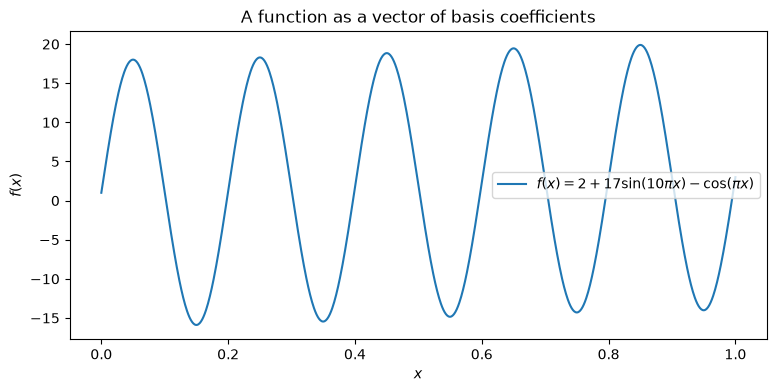

In [6]:
# Plot the three basis functions and their linear combination.
x = np.linspace(0, 1, 1000)

phi1 = np.ones_like(x)
phi2 = np.sin(10 * np.pi * x)
phi3 = np.cos(np.pi * x)

f = 2*phi1 + 17*phi2 - phi3

plt.figure(figsize=(9, 4))
plt.plot(x, f, label=r"$f(x)=2+17\sin(10\pi x)-\cos(\pi x)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.title("A function as a vector of basis coefficients")
plt.legend()
plt.show()

## 9. Operators

An **operator** is a map between spaces.

In the functional-analytic setting we may have

$$
A:U\to V,
$$

where $U$ and $V$ are normed, Banach, or Hilbert spaces.

Several properties are especially important.

### Linearity

$$
A(\alpha u+\beta v)
=
\alpha A(u)+\beta A(v).
$$

### Boundedness

There exists $C>0$ such that

$$
\|Au\|_V
\leq
C\|u\|_U
\qquad
\forall u\in U.
$$

### Isometry

$$
\|Au\|_V=\|u\|_U.
$$

For linear operators between normed spaces, boundedness and continuity are equivalent.

### Example: a matrix as an operator

A matrix

$$
A\in\mathbb R^{m\times n}
$$

defines

$$
A:\mathbb R^n\to\mathbb R^m.
$$

This is the finite-dimensional case of the same concept.

For example,

$$
A=
\begin{pmatrix}
2&0\\
0&1
\end{pmatrix}
$$

stretches one direction by a factor of $2$.

Functional analysis asks us to study analogous transformations when $u$ is a function or an infinite sequence.

### Example: the derivative operator

Consider

$$
D:C^1([0,1])\to C([0,1]),
\qquad
Df=f'.
$$

This operator is linear.

With suitable norms it can also be bounded. For example, if the domain is equipped with

$$
\|f\|_{C^1}
=
\|f\|_\infty+\|f'\|_\infty,
$$

then

$$
\|Df\|_\infty
=
\|f'\|_\infty
\leq
\|f\|_{C^1}.
$$

But if we instead put only the supremum norm on the domain, differentiation is not bounded:

$$
f_n(x)=\frac{\sin(nx)}{n}
$$

satisfies

$$
\|f_n\|_\infty=\frac1n\to0,
$$

while

$$
\|Df_n\|_\infty
=
\|\cos(nx)\|_\infty
=
1.
$$

This is an important lesson: **boundedness depends on the spaces and their norms, not only on the formula defining the operator.**

In [7]:
# Numerical illustration of the derivative example.
x = np.linspace(0, 1, 2000)

n_values = [1, 5, 20, 100]

for n in n_values:
    f = np.sin(n*x) / n
    df = np.cos(n*x)

    print(
        f"n={n:3d}: ||f_n||_inf={np.max(np.abs(f)):.5f}, "
        f"||Df_n||_inf={np.max(np.abs(df)):.5f}"
    )

n=  1: ||f_n||_inf=0.84147, ||Df_n||_inf=1.00000
n=  5: ||f_n||_inf=0.20000, ||Df_n||_inf=1.00000
n= 20: ||f_n||_inf=0.05000, ||Df_n||_inf=1.00000
n=100: ||f_n||_inf=0.01000, ||Df_n||_inf=1.00000


## 10. Adjoint operators

Let $V$ be a Hilbert space and

$$
A:V\to V
$$

be a suitable linear operator.

Its **adjoint** $A^*$ is defined by

$$
\langle Au,v\rangle
=
\langle u,A^*v\rangle
$$

for all $u,v$ in the appropriate domain.

In finite dimensions, this is familiar:

$$
A^*=A^\top
$$

for real matrices, and

$$
A^*=A^\dagger
$$

for complex matrices.

A particularly important class is the **self-adjoint operators**:

$$
A^*=A.
$$

These operators are central to spectral theory.

In [8]:
# In finite dimensions, verify the adjoint identity numerically.
rng = np.random.default_rng(3)

A = rng.normal(size=(4, 4))
u = rng.normal(size=4)
v = rng.normal(size=4)

left = np.dot(A @ u, v)
right = np.dot(u, A.T @ v)

print("Difference:", abs(left - right))

Difference: 4.440892098500626e-16


## 11. Functionals and the dual space

An operator can map one vector to another vector. A **functional** maps a vector to a scalar.

Thus

$$
\varphi:V\to\mathbb C.
$$

A linear functional satisfies

$$
\varphi(\alpha u+\beta v)
=
\alpha\varphi(u)+\beta\varphi(v).
$$

The continuous linear functionals form the **dual space**

$$
V^*
=
\{\varphi:V\to\mathbb C
\mid
\varphi\text{ is linear and continuous}\}.
$$

The source describes functionals as scalar-valued probes of vectors and introduces the dual space in exactly this way.

### Example: evaluation on $C([0,1])$

Define

$$
\varphi_x(f)=f(x)
$$

for some fixed $x\in[0,1]$.

This is linear:

$$
\varphi_x(\alpha f+\beta g)
=
\alpha f(x)+\beta g(x).
$$

It is also continuous with respect to the supremum norm because

$$
|\varphi_x(f)|
=
|f(x)|
\leq
\|f\|_\infty.
$$

Thus

$$
\varphi_x\in C([0,1])^*.
$$

This is a very concrete example of a functional: it simply asks a function for its value at a particular point.

### A useful non-example: point evaluation on $L^2$

It is tempting to define

$$
\varphi_x(f)=f(x)
$$

on $L^2([0,1])$ as well.

This is **not** a well-defined functional on $L^2$ in the usual sense.

Why?

Elements of $L^2$ are equivalence classes of functions that agree almost everywhere. Changing a function at a single point does not change its $L^2$ class, but it can change its point value.

Therefore $f(x)$ is not determined by the $L^2$ element.

This is an important example of why the precise choice of function space matters.

## 12. The Riesz representation theorem

A deeper and extremely useful fact about Hilbert spaces is the **Riesz representation theorem**.

If $H$ is a Hilbert space and

$$
\varphi:H\to\mathbb C
$$

is a continuous linear functional, then there exists a unique vector

$$
y\in H
$$

such that

$$
\varphi(x)
=
\langle x,y\rangle
$$

for every $x\in H$.

Thus, in a Hilbert space,

$$
\boxed{
H^*\cong H.
}
$$

*The theorem explains why inner products are so powerful: every continuous linear functional can be represented by taking an inner product with a fixed vector.*

This is one of the standard foundational results of functional analysis; Conway's treatment places Hilbert spaces and operators at the beginning of a systematic development of the subject.

### Example in $\mathbb R^n$

Let

$$
\varphi(x)=a^\top x.
$$

Then

$$
\varphi(x)
=
\langle x,a\rangle.
$$

So the representing vector is simply $a$.

*The Riesz theorem says that the same idea survives in arbitrary Hilbert spaces, including infinite-dimensional ones.*

## 13. Strong and weak convergence

There are different notions of convergence in infinite-dimensional spaces.

### Strong convergence

A sequence $v_n$ converges **strongly** to $v$ if

$$
\|v_n-v\|\to0.
$$

This is ordinary norm convergence.

### Weak convergence

In a Hilbert space,

$$
v_n\rightharpoonup v
$$

if

$$
\langle v_n,w\rangle
\to
\langle v,w\rangle
$$

for every fixed $w\in V$.

So weak convergence says that the vectors become indistinguishable when tested against every fixed vector.

Strong convergence implies weak convergence, but the converse need not hold.

The source introduces exactly this distinction and uses it in its discussion of compact operators.

### Example: the standard basis in $\ell^2$

Let

$$
e_n=(0,\ldots,0,1,0,\ldots)
$$

with the $1$ in the $n$-th position.

Then

$$
\|e_n\|_2=1
$$

for every $n$.

Therefore $e_n$ does **not** converge strongly to $0$.

But for any fixed $x=(x_1,x_2,\ldots)\in\ell^2$,

$$
\langle e_n,x\rangle=x_n\to0.
$$

Hence

$$
e_n\rightharpoonup0
$$

weakly.

This is one of the canonical examples showing that weak and strong convergence are genuinely different.

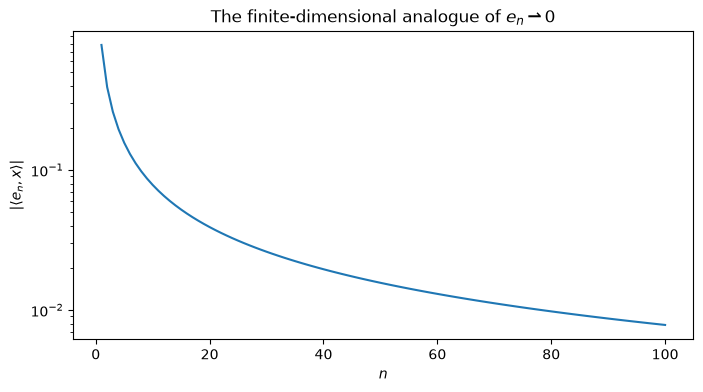

In [9]:
# Numerical illustration using a finite truncation of l2.
dimension = 100

basis = np.eye(dimension)

# A fixed l2 vector with decaying coordinates.
n = np.arange(1, dimension + 1)
x = 1 / n
x = x / np.linalg.norm(x)

inner_products = basis @ x

plt.figure(figsize=(8, 4))
plt.semilogy(n, np.abs(inner_products))
plt.xlabel(r"$n$")
plt.ylabel(r"$|\langle e_n,x\rangle|$")
plt.title(r"The finite-dimensional analogue of $e_n\rightharpoonup0$")
plt.show()

## 14. Compact operators

A compact operator is, roughly speaking, an operator that turns bounded or weakly convergent sequences into sequences with stronger convergence properties.

The source states the Hilbert-space formulation:

$$
v_n\rightharpoonup v
\quad\Longrightarrow\quad
Av_n\to Av.
$$

The convergence on the right is **strong**.

This is a remarkable strengthening: a compact operator can turn weak information into norm convergence.

Compact operators are important because they behave in many ways like finite-dimensional operators and have particularly tractable spectral properties.

### Example: a diagonal compact operator on $\ell^2$

Define

$$
A(x_1,x_2,x_3,\ldots)
=
\left(
x_1,\frac{x_2}{2},\frac{x_3}{3},\ldots
\right).
$$

Then

$$
Ae_n=\frac1n e_n.
$$

Since

$$
\|Ae_n\|_2=\frac1n\to0,
$$

the operator compresses the high-index directions.

This is the simplest prototype of a compact diagonal operator: its diagonal entries tend to zero.

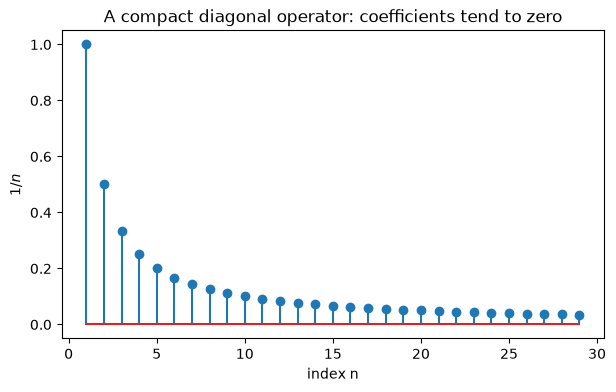

In [10]:
# Visualise the decay of the singular/eigenvalue-like diagonal entries.
n = np.arange(1, 30)
eigenvalues = 1 / n

plt.figure(figsize=(7, 4))
plt.stem(n, eigenvalues)
plt.xlabel("index n")
plt.ylabel(r"$1/n$")
plt.title("A compact diagonal operator: coefficients tend to zero")
plt.show()

### Non-example: the identity operator on $\ell^2$

Consider

$$
I(x)=x.
$$

We have

$$
Ie_n=e_n.
$$

The sequence $e_n$ converges weakly to $0$, but

$$
\|Ie_n\|_2=\|e_n\|_2=1.
$$

Therefore the identity does not turn this weakly convergent sequence into a strongly convergent one.

Hence the identity operator on infinite-dimensional $\ell^2$ is **not compact**.

This highlights an important difference between finite and infinite dimensions: the identity operator on a finite-dimensional space is compact, but on an infinite-dimensional normed space it is not.

## 15. Rank and finite-dimensional intuition

The **rank** of an operator $A$ is the dimension of its image:

$$
\operatorname{rank}(A)
=
\dim(\operatorname{im}A).
$$

For a matrix this is familiar.

For operators on function spaces, the image may itself be an infinite-dimensional space.

For example, the differentiation operator

$$
D:C^1([0,1])\to C([0,1])
$$

has infinite-dimensional image because derivatives of polynomials can produce arbitrarily high-degree polynomials.

By contrast, an operator of the form

$$
Af
=
\left(\int_0^1 f(x)\,dx\right)g
$$

has rank at most $1$, because every output is a scalar multiple of the single function $g$.

This latter type is a **finite-rank operator**.

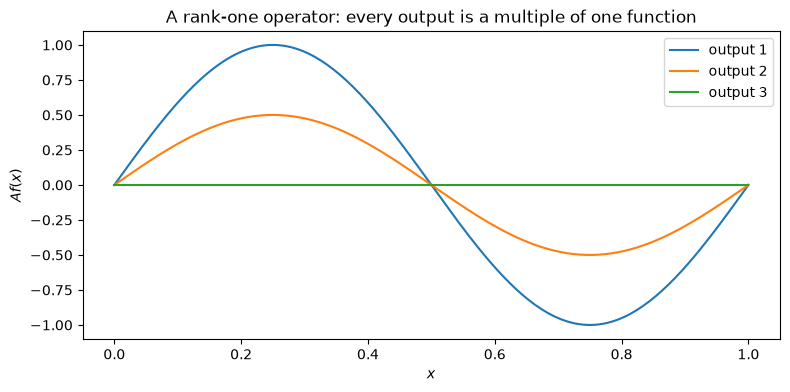

In [11]:
# A rank-one operator on discretised functions.
x = np.linspace(0, 1, 200)
g = np.sin(2 * np.pi * x)

def rank_one_operator(f):
    # Approximate the integral using the trapezoidal rule.
    from scipy.integrate import trapezoid
    coefficient = trapezoid(f, x)
    return coefficient * g

# Apply the operator to several different functions.
functions = [
    np.ones_like(x),
    x,
    np.sin(4 * np.pi * x),
]

outputs = [rank_one_operator(f) for f in functions]

plt.figure(figsize=(9, 4))
for i, out in enumerate(outputs, start=1):
    plt.plot(x, out, label=f"output {i}")

plt.xlabel(r"$x$")
plt.ylabel(r"$Af(x)$")
plt.title("A rank-one operator: every output is a multiple of one function")
plt.legend()
plt.show()

## 16. Operator norms

For a bounded linear operator

$$
A:U\to V,
$$

its **operator norm** is

$$
\|A\|_{\mathrm{op}}
=
\sup_{u\neq0}
\frac{\|Au\|_V}{\|u\|_U}.
$$

Equivalently,

$$
\|A\|_{\mathrm{op}}
=
\sup_{\|u\|_U=1}\|Au\|_V.
$$

It is the smallest constant $C$ for which

$$
\|Au\|_V\leq C\|u\|_U
$$

holds for every $u$.

Thus the operator norm measures the largest amount by which $A$ can stretch vectors.

In finite dimensions this is the familiar induced matrix norm.

In [12]:
# Estimate the Euclidean operator norm of a matrix
# using its largest singular value.
A = np.array([
    [3.0, 1.0],
    [0.0, 2.0]
])

singular_values = np.linalg.svd(A, compute_uv=False)
operator_norm = singular_values[0]

print("Singular values:", singular_values)
print("Operator norm:", operator_norm)

Singular values: [3.25661654 1.84240298]
Operator norm: 3.2566165379829393


## 17. Putting the hierarchy together

The main objects introduced in this chapter fit into a useful hierarchy:

$$
\boxed{
\begin{array}{c}
\text{vector space}\\
\downarrow\\
\text{normed space}\\
\downarrow\\
\text{Banach space}
\end{array}
}
$$

and, independently,

$$
\boxed{
\begin{array}{c}
\text{inner-product space}\\
\downarrow\\
\text{Hilbert space}
\end{array}
}
$$

with every Hilbert space automatically being a Banach space because an inner product induces a norm.

Then we study maps acting on these spaces:

$$
\text{operators}
\qquad\text{and}\qquad
\text{functionals}.
$$

For Hilbert spaces, the inner product additionally gives us:

$$
\text{adjoints}
\longrightarrow
\text{self-adjoint operators}
\longrightarrow
\text{spectral theory}.
$$

This is precisely why functional analysis appears immediately before spectral theory in the mathematical foundations for GDL. citeturn4view0

## 18. Why this matters for Geometric Deep Learning

The immediate purpose of this chapter is preparation for spectral theory.

A graph, grid, or manifold gives us a domain $\Omega$ and a space of signals

$$
\mathcal X(\Omega).
$$

Once this signal space is viewed as a normed or Hilbert space, we can study operators

$$
A:\mathcal X(\Omega)\to\mathcal X(\Omega).
$$

Important geometric operators—most notably Laplacian-type operators—then become objects whose eigenfunctions and eigenvalues can be studied.

Schematically,

$$
\boxed{
\text{domain}
\rightarrow
\text{signal space}
\rightarrow
\text{operator}
\rightarrow
\text{spectrum}.
}
$$

That chain will be central when we move to the next chapter on spectral theory.

## Summary

Functional analysis extends familiar linear algebra to spaces that may be infinite-dimensional.

The essential chain is:

$$
\boxed{
\begin{aligned}
&\text{Cauchy sequences}
\\
&\downarrow
\\
&\text{completeness}
\\
&\downarrow
\\
&\text{Banach spaces}
\\
&\downarrow
\\
&\text{Hilbert spaces}
\\
&\downarrow
\\
&\text{operators and functionals}
\\
&\downarrow
\\
&\text{spectral theory}.
\end{aligned}
}
$$

The most important conceptual shift is to become comfortable treating **functions as vectors**.

Once we do that, notions such as

$$
\text{orthogonality},
\quad
\text{projection},
\quad
\text{basis},
\quad
\text{operator},
\quad
\text{eigenfunction}
$$

become natural extensions of ideas already familiar from finite-dimensional linear algebra.

This is the functional-analytic language needed for the next stage: **spectral theory**.

## 19. Exercises

### Exercise 1 — Cauchy sequences

Determine whether each sequence is Cauchy in $\mathbb R$:

$$
x_n=\frac1n,
\qquad
y_n=(-1)^n,
\qquad
z_n=1-\frac1n.
$$

### Exercise 2 — Completeness

Explain why

$$
(0,1)
$$

with the usual metric is not complete.

Find another Cauchy sequence whose limit is missing from the space.

### Exercise 3 — $\ell^p$

Determine which of the following sequences belong to $\ell^1$, $\ell^2$, and $\ell^\infty$:

$$
x_n=\frac1n,
\qquad
y_n=\frac1{\sqrt n},
\qquad
z_n=\frac1{n^2}.
$$

### Exercise 4 — Hilbert space

Use the parallelogram identity to determine whether the $\ell^\infty$ norm on $\mathbb R^2$ comes from an inner product.

### Exercise 5 — Weak versus strong convergence

Prove that

$$
e_n\rightharpoonup0
$$

in $\ell^2$, but

$$
e_n\nrightarrow0
$$

in norm.

### Exercise 6 — Functionals

Show that

$$
\varphi(f)=\int_0^1 f(x)\,dx
$$

is a continuous linear functional on $C([0,1])$ with the supremum norm.

Find a bound for its operator norm.

### Exercise 7 — Operators

Consider

$$
(Af)(x)=x f(x)
$$

on $L^2([0,1])$.

Show that $A$ is linear and bounded, and determine $\|A\|_{\mathrm{op}}$.

### Exercise 8 — Compactness

Consider

$$
A(e_n)=\frac1n e_n
$$

on $\ell^2$.

Explain why this suggests compactness, and compare it with the identity operator.

### Exercise 9 — Infinite-dimensional coordinates

Choose a familiar function on $[0,1]$ and approximate it using the first few Fourier basis functions. Investigate how the approximation changes as the number of modes increases.

## References

### Primary source

1. H. Sáez de Ocáriz Borde and M. Bronstein,  
   **Mathematical Foundations of Geometric Deep Learning**, arXiv:2508.02723, 2025.  
   Chapter 5, *Functional Analysis*.

### Functional analysis references

2. J. B. Conway,  
   **A Course in Functional Analysis**, 2nd ed., Springer, 1990/2007.  
   A comprehensive graduate-level reference covering Hilbert spaces, Banach spaces, operators, duality, and spectral theory. 

3. E. Kreyszig,  
   **Introductory Functional Analysis with Applications**, Wiley.  
   Particularly useful for an applications-oriented introduction to metric and normed spaces, Banach spaces, Hilbert spaces, and operators.

4. W. Rudin,  
   **Functional Analysis**, 2nd ed., McGraw–Hill, 1991.  
   A more concise and rigorous reference for normed spaces, Banach spaces, Hilbert spaces, and operator theory.

5. M. Reed and B. Simon,  
   **Methods of Modern Mathematical Physics, Vol. I: Functional Analysis**, Academic Press.  
   Particularly relevant for the connection between functional analysis, Hilbert spaces, and mathematical physics.

6. E. M. Stein and R. Shakarchi,  
   **Functional Analysis: Introduction to Further Topics in Analysis**, Princeton University Press, 2011.  
   Useful for connecting functional analysis with Fourier analysis and other parts of analysis.

### Related background

7. `03_linear_spaces.ipynb` — vector spaces, norms, metrics, and inner products.

8. `05_geometric_priors-i.ipynb` — signals on domains and the geometric viewpoint that motivates studying operators on signal spaces.